<a href="https://colab.research.google.com/github/KU-BIG/KUBIG_2026_SPRING/blob/main/KUBIG%20CONTEST/ML%20Team%201/%E1%84%86%E1%85%A9%E1%84%83%E1%85%A6%E1%86%AF%E1%84%85%E1%85%B5%E1%86%BC_%E1%84%89%E1%85%A6%E1%84%80%E1%85%B2%E1%86%AB%E1%84%89%E1%85%A5%E1%86%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/Users/jiyu/고려대학교 통계대학원/쿠빅/ML 스터디/팀 프로젝트/데이터셋/df_final.csv')
df=df.drop(columns='Unnamed: 0')
df.head()

,year,week,rain_nat,erer,rain_diff,water_temp,DO,BOD,COD,pH,...,cases_bacteria,cases_virus,cases_protozoa,temp,humidity,pop_area,sum_weighted_area,sum_flood_area,avg_flood_intensity,pop_weighted_intensity
0,2015,1.0,3.772672,0.0,3.772672,1.701246,15.622046,1.936856,3.764894,6.748502,...,6,89,2,-0.262836,3.199137,0.0,0.0,0.0,0.0,0.0
1,2015,2.0,1.185419,0.0,-2.587254,3.712223,13.466400,2.436846,4.732934,7.682216,...,12,78,1,-0.013854,3.658332,0.0,0.0,0.0,0.0,0.0
2,2015,3.0,2.691617,0.0,1.506199,3.724155,14.035902,2.379334,4.717393,7.709611,...,13,117,5,0.037085,3.580605,0.0,0.0,0.0,0.0,0.0
3,2015,4.0,2.586522,0.0,-0.105095,3.998386,13.746543,1.649368,4.705090,7.859229,...,22,205,3,0.100451,4.251323,0.0,0.0,0.0,0.0,0.0
4,2015,5.0,0.509471,0.0,-2.077051,5.263631,13.063065,3.622871,5.704383,7.775275,...,18,201,2,0.006128,4.068619,0.0,0.0,0.0,0.0,0.0


In [ ]:
# 월 변수 생성

df['year']=df['year'].astype(int)
df['week']=df['week'].astype(int)

def first_saturday_of_year(y: int)->pd.Timestamp:
    jan1=pd.Timestamp(f'{y}-01-01')
    days_ahead=(5-jan1.weekday())%7
    return jan1+pd.Timedelta(days=days_ahead)

first_sat=df['year'].map(first_saturday_of_year)
df['week_start']=first_sat+pd.to_timedelta(7*(df['week']-1), unit='D')

df['month']=df['week_start'].dt.month

df.head()

,year,week,rain_nat,erer,rain_diff,water_temp,DO,BOD,COD,pH,...,cases_protozoa,temp,humidity,pop_area,sum_weighted_area,sum_flood_area,avg_flood_intensity,pop_weighted_intensity,week_start,month
0,2015,1,3.772672,0.0,3.772672,1.701246,15.622046,1.936856,3.764894,6.748502,...,2,-0.262836,3.199137,0.0,0.0,0.0,0.0,0.0,2015-01-03,1
1,2015,2,1.185419,0.0,-2.587254,3.712223,13.466400,2.436846,4.732934,7.682216,...,1,-0.013854,3.658332,0.0,0.0,0.0,0.0,0.0,2015-01-10,1
2,2015,3,2.691617,0.0,1.506199,3.724155,14.035902,2.379334,4.717393,7.709611,...,5,0.037085,3.580605,0.0,0.0,0.0,0.0,0.0,2015-01-17,1
3,2015,4,2.586522,0.0,-0.105095,3.998386,13.746543,1.649368,4.705090,7.859229,...,3,0.100451,4.251323,0.0,0.0,0.0,0.0,0.0,2015-01-24,1
4,2015,5,0.509471,0.0,-2.077051,5.263631,13.063065,3.622871,5.704383,7.775275,...,2,0.006128,4.068619,0.0,0.0,0.0,0.0,0.0,2015-01-31,1


# 1 지연상관 확인

In [ ]:
df2=df.drop(columns=['year', 'month', 'week', 'week_start', 'cases_virus', 'cases_protozoa'])
df2=df2.rename(columns={'cases_bacteria':'cases'})

In [ ]:
def lag_correlation_all(df, targets, max_lag=8):
    results=[]
    feature_cols=df.columns.drop(targets)

    for target in targets:

        for col in feature_cols:
            for k in range(0, max_lag+1):
                corr=df[target].corr(df[col].shift(k))
                results.append({
                    'target':target,
                    'feature':col,
                    'lag':k,
                    'correlation':corr
                })
    return pd.DataFrame(results)

In [ ]:
targets=['cases']

lag_corr_df=lag_correlation_all(df2, targets)

In [ ]:
top2=(
    lag_corr_df.assign(abs_corr=lambda x: x['correlation'].abs()).groupby(
        ['target', 'feature']).apply(lambda x: x.nlargest(3, 'abs_corr'))
)

top2

/var/folders/wq/1x7x1d114_n4k095bzh0h8640000gn/T/ipykernel_1217/3689244599.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ['target', 'feature']).apply(lambda x: x.nlargest(3, 'abs_corr'))


target                 feature  lag  \
target feature                                                          
cases  BOD                    45   cases                     BOD    0   
                              46   cases                     BOD    1   
                              47   cases                     BOD    2   
       COD                    62   cases                     COD    8   
                              61   cases                     COD    7   
                              60   cases                     COD    6   
       DO                     38   cases                      DO    2   
                              39   cases                      DO    3   
                              37   cases                      DO    1   
       avg_flood_intensity    135  cases     avg_flood_intensity    0   
                              137  cases     avg_flood_intensity    2   
                              138  cases     avg_flood_intensity    3   
       coli_log_mean          73   cases           coli_log_mean    1   
                              75   cases           coli_log_mean    3   
                              72   cases           coli_log_mean    0   
       coli_mean              84   cases               coli_mean    3   
                              82   cases               coli_mean    1   
                              81   cases               coli_mean    0   
       erer                   12   cases                    erer    3   
                              9    cases                    erer    0   
                              11   cases                    erer    2   
       humidity               100  cases                humidity    1   
                              99   cases                humidity    0   
                              101  cases                humidity    2   
       pH                     71   cases                      pH    8   
                              70   cases                      pH    7   
                              69   cases                      pH    6   
       pop_area               108  cases                pop_area    0   
                              110  cases                pop_area    2   
                              109  cases                pop_area    1   
       pop_weighted_intensity 144  cases  pop_weighted_intensity    0   
                              146  cases  pop_weighted_intensity    2   
                              147  cases  pop_weighted_intensity    3   
       rain_diff              21   cases               rain_diff    3   
                              24   cases               rain_diff    6   
                              25   cases               rain_diff    7   
       rain_nat               3    cases                rain_nat    3   
                              0    cases                rain_nat    0   
                              2    cases                rain_nat    2   
       sum_flood_area         126  cases          sum_flood_area    0   
                              128  cases          sum_flood_area    2   
                              127  cases          sum_flood_area    1   
       sum_weighted_area      117  cases       sum_weighted_area    0   
                              119  cases       sum_weighted_area    2   
                              118  cases       sum_weighted_area    1   
       temp                   92   cases                    temp    2   
                              91   cases                    temp    1   
                              93   cases                    temp    3   
       water_temp             29   cases              water_temp    2   
                              30   cases              water_temp    3   
                              28   cases              water_temp    1   

                                   correlation  abs_corr  
target feature                                            
cases  BOD                    45     -0.223856

# 2 자기 상관

In [ ]:
df2=df.drop(columns=['week', 'week_start', 'cases_virus', 'cases_protozoa'])
df2=df2.rename(columns={'cases_bacteria':'cases'})
df2.columns

Index(['year', 'rain_nat', 'erer', 'rain_diff', 'water_temp', 'DO', 'BOD',
       'COD', 'pH', 'coli_log_mean', 'coli_mean', 'cases', 'temp', 'humidity',
       'pop_area', 'sum_weighted_area', 'sum_flood_area',
       'avg_flood_intensity', 'pop_weighted_intensity', 'month'],
      dtype='object')

<Figure size 640x480 with 0 Axes>

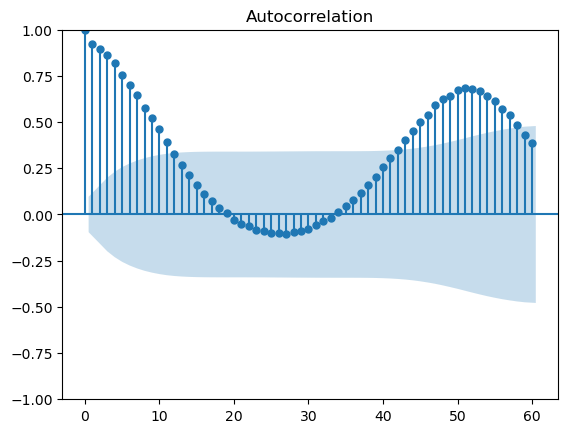

<Figure size 640x480 with 0 Axes>

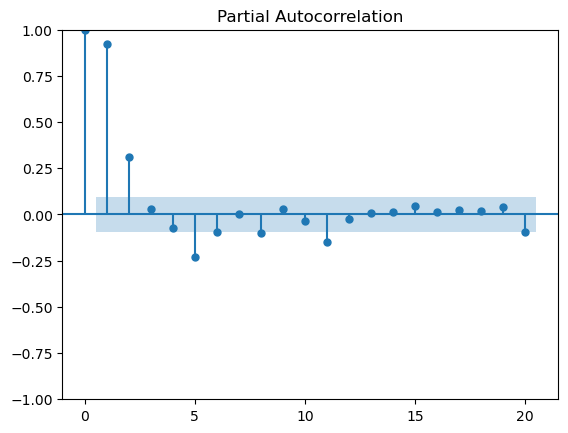

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure()
plot_acf(df2['cases'], lags=60)
plt.show()

plt.figure()
plot_pacf(df2['cases'], lags=20)
plt.show()

# 3 모델링

## 2.1 base model

### 2.1.1 최종 전처리

In [ ]:
df=df.sort_values(['year', 'week'])

df2=df.drop(columns=['week', 'week_start', 'cases_virus', 'cases_protozoa'])
df2=df2.rename(columns={'cases_bacteria':'cases'})
df2.columns

# 계절성 변수 추가
df2['month_sin']=np.sin(2*np.pi*df2['month']/12)
df2['month_cos']=np.cos(2*np.pi*df2['month']/12)

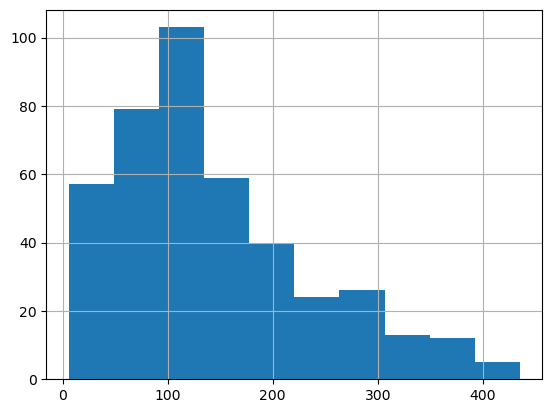

In [ ]:
# 타겟 변수 분포 확인 -> 한쪽으로 치우친 분포이기에 Log 변환 필요
df2.cases.hist()

df2['cases']=np.log1p(df2['cases'])

In [ ]:
# 지연 변수 생성 함수
def make_lag(df, cols, lags):
    df=df.copy()

    for c in cols:
        for l in lags:
            df[f'{c}_lag{l}']=df[c].shift(l)
    return df

In [ ]:
# 지연 변수 생성
cols=['rain_nat', 'erer', 'rain_diff']
#cols=['erer', 'rain_diff']
df3=make_lag(df2, cols, [3])

cols=['pop_area', 'sum_weighted_area', 'sum_flood_area','avg_flood_intensity', 'pop_weighted_intensity']
#cols=['avg_flood_intensity', 'sum_weighted_area']
df3=make_lag(df3, cols, [2])

cols=['cases']
df3=make_lag(df3, cols, [0, 1, 2, 3])

cols=['temp', 'humidity']
#cols=['temp']
df3=make_lag(df3, cols, [0, 1, 2])

In [ ]:
df3.columns

Index(['year', 'rain_nat', 'erer', 'rain_diff', 'water_temp', 'DO', 'BOD',
       'COD', 'pH', 'coli_log_mean', 'coli_mean', 'cases', 'temp', 'humidity',
       'pop_area', 'sum_weighted_area', 'sum_flood_area',
       'avg_flood_intensity', 'pop_weighted_intensity', 'month', 'month_sin',
       'month_cos', 'rain_nat_lag3', 'erer_lag3', 'rain_diff_lag3',
       'pop_area_lag2', 'sum_weighted_area_lag2', 'sum_flood_area_lag2',
       'avg_flood_intensity_lag2', 'pop_weighted_intensity_lag2', 'cases_lag0',
       'cases_lag1', 'cases_lag2', 'cases_lag3', 'temp_lag0', 'temp_lag1',
       'temp_lag2', 'humidity_lag0', 'humidity_lag1', 'humidity_lag2'],
      dtype='object')

In [ ]:
# 중복 변수 삭제
df4=df3.drop(columns=['rain_nat', 'erer', 'rain_diff', 'pop_area', 'sum_weighted_area', 'sum_flood_area',
       'avg_flood_intensity', 'pop_weighted_intensity', 'temp', 'humidity', 'month', 'cases_lag0', 'water_temp', 'water_temp', 'DO', 'BOD', 'COD', 'pH','coli_log_mean', 'coli_mean'])

# 'water_temp', 'DO', 'BOD', 'COD', 'pH','coli_log_mean', 'coli_mean'

In [ ]:
df4.columns

Index(['year', 'cases', 'month_sin', 'month_cos', 'rain_nat_lag3', 'erer_lag3',
       'rain_diff_lag3', 'pop_area_lag2', 'sum_weighted_area_lag2',
       'sum_flood_area_lag2', 'avg_flood_intensity_lag2',
       'pop_weighted_intensity_lag2', 'cases_lag1', 'cases_lag2', 'cases_lag3',
       'temp_lag0', 'temp_lag1', 'temp_lag2', 'humidity_lag0', 'humidity_lag1',
       'humidity_lag2'],
      dtype='object')

In [ ]:
# test/train set 분리 : 2022년 test set으로, 나머지 train set으로 분리

df_test=df4.loc[df4['year']==2022, :]
df_train=df4.loc[df4['year'].isin(range(2015, 2022)), :]

df_test=df_test.drop(columns='year')
df_train=df_train.drop(columns='year')

X_train=df_train.drop(columns='cases')
y_train=df_train['cases']

X_test=df_test.drop(columns='cases')
y_test=df_test['cases']

### 2.1.2 RandomForest

In [ ]:
# TimeSeriesSplit 활용하여 하이퍼파라미터 튜닝

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# -------------------------
# 1) scoring: RMSE (작을수록 좋게)
# -------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

# -------------------------
# 2) TimeSeriesSplit
# -------------------------
tscv = TimeSeriesSplit(n_splits=5)

# -------------------------
# 3) Pipeline + 탐색공간
# -------------------------
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist = {
    "model__n_estimators": [200, 500, 800, 1200],
    "model__max_depth": [None, 3, 5, 8, 12, 20],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8, 12],
    "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0],
    "model__bootstrap": [True, False]
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring=rmse_scorer,
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
    refit=True,                # CV로 best 찾은 다음, train 전체로 다시 학습
    return_train_score=True
)

# -------------------------
# 4) 튜닝 + CV 성능 확인
# -------------------------
search.fit(X_train, y_train)

cv_best_rmse = -search.best_score_
print("CV best RMSE:", cv_best_rmse)
print("Best params:", search.best_params_)

CV best RMSE: 0.2961507383509615
Best params: {'model__n_estimators': 1200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 0.7, 'model__max_depth': 20, 'model__bootstrap': True}


In [ ]:
best_model=search.best_estimator_

y_pred=best_model.predict(X_test)

test_rmse=np.sqrt(mean_squared_error(y_test, y_pred))
bias = (y_test - y_pred).mean()
normalized_rmse=test_rmse/y_test.mean()
print("TEST RMSE:", test_rmse)
print("TEST Bias (mean resid):", bias)
print('Normalized RMSE:', normalized_rmse)

TEST RMSE: 0.1587919722771281
TEST Bias (mean resid): 0.02204641439772382
Normalized RMSE: 0.031444857928209544


In [ ]:
final_rf=best_model.named_steps['model']

imp = pd.Series(final_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 20 feature importance:")
print(imp.head(30))


Top 20 feature importance:
cases_lag1                     0.578677
cases_lag2                     0.275726
cases_lag3                     0.068935
temp_lag0                      0.019580
month_cos                      0.011518
temp_lag1                      0.010070
temp_lag2                      0.009956
rain_diff_lag3                 0.005040
humidity_lag0                  0.005032
rain_nat_lag3                  0.003954
humidity_lag2                  0.003923
humidity_lag1                  0.003446
month_sin                      0.002353
erer_lag3                      0.000895
pop_weighted_intensity_lag2    0.000279
sum_flood_area_lag2            0.000177
sum_weighted_area_lag2         0.000165
pop_area_lag2                  0.000160
avg_flood_intensity_lag2       0.000112
dtype: float64


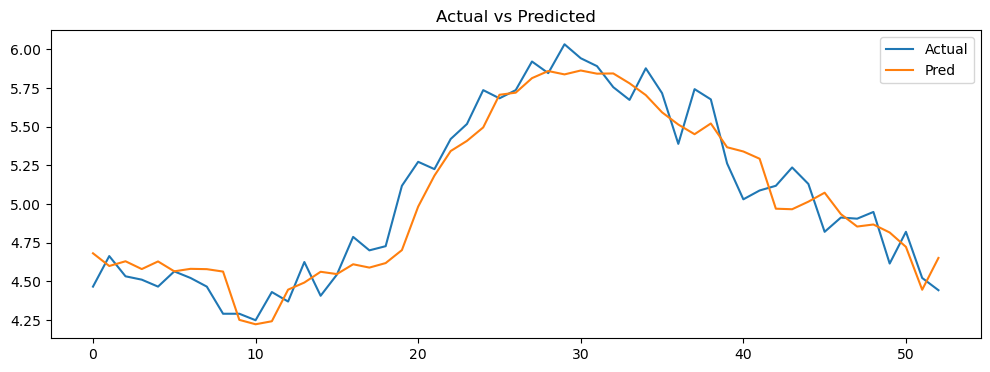

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Pred")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
# 극한 발생수 예측

threshold = np.percentile(y_train, 90)

high_risk_true = y_test > threshold
high_risk_pred = y_pred > threshold

recall = (high_risk_true & high_risk_pred).sum() / high_risk_true.sum()
print("High-risk recall:", recall)

High-risk recall: 0.7142857142857143


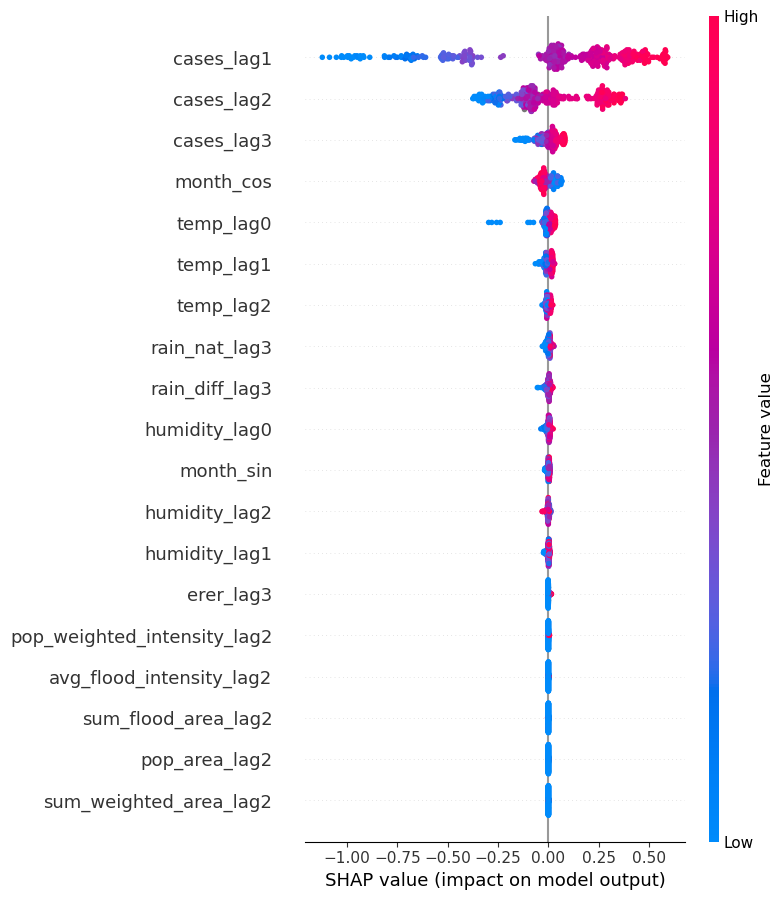

In [ ]:
import shap

explainer = shap.TreeExplainer(final_rf)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

### 2.1.3 XGBoost

In [ ]:
# TimeSeriesSplit 활용하여 하이퍼파라미터 튜닝

import numpy as np
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, mean_squared_error
import xgboost as xgb

# -------------------------
# 1) scoring: RMSE (작을수록 좋게)
# -------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

# -------------------------
# 2) TimeSeriesSplit
# -------------------------
tscv = TimeSeriesSplit(n_splits=5)

# -------------------------
# 3) Pipeline + 탐색공간
# -------------------------
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", xgb.XGBRegressor(random_state=42, objective="reg:squarederror", verbosity=0))
])

param_dist = {
    "model__n_estimators": [300, 500, 800, 1200],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],

    # 트리 복잡도
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__min_child_weight": [1, 3, 5, 7],   # LGB의 min_child_samples와 유사 개념

    # 샘플링
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],

    # 정규화
    "model__reg_alpha": [0, 0.1, 0.5, 1.0],
    "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],

    # 추가로 넣으면 좋은 것
    "model__gamma": [0, 0.1, 0.3, 0.5],   # 분할 최소 손실 감소량
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring=rmse_scorer,
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
    refit=True,                # CV로 best 찾은 다음, train 전체로 다시 학습
    return_train_score=True
)

# -------------------------
# 4) 튜닝 + CV 성능 확인
# -------------------------
search.fit(X_train, y_train)

cv_best_rmse = -search.best_score_
print("CV best RMSE:", cv_best_rmse)
print("Best params:", search.best_params_)


CV best RMSE: 0.3044978965850743
Best params: {'model__subsample': 1.0, 'model__reg_lambda': 1.0, 'model__reg_alpha': 0.1, 'model__n_estimators': 300, 'model__min_child_weight': 5, 'model__max_depth': 2, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__colsample_bytree': 0.9}


In [ ]:
best_model=search.best_estimator_

y_pred=best_model.predict(X_test)

test_rmse=np.sqrt(mean_squared_error(y_test, y_pred))
bias = (y_test - y_pred).mean()
normalized_rmse=test_rmse/y_test.mean()
print("TEST RMSE:", test_rmse)
print("TEST Bias (mean resid):", bias)
print('Normalized RMSE:', normalized_rmse)

TEST RMSE: 0.21145126336477732
TEST Bias (mean resid): 0.022735969209404808
Normalized RMSE: 0.04187273978587362


In [ ]:
final_xgb=best_model.named_steps['model']

imp = pd.Series(final_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 20 feature importance:")
print(imp.head(30))


Top 20 feature importance:
cases_lag1                     0.646132
cases_lag2                     0.183887
month_cos                      0.033367
cases_lag3                     0.027053
temp_lag1                      0.014679
temp_lag0                      0.012384
avg_flood_intensity_lag2       0.011130
rain_nat_lag3                  0.010821
humidity_lag0                  0.010189
month_sin                      0.009591
rain_diff_lag3                 0.005720
humidity_lag1                  0.005662
pop_area_lag2                  0.005591
temp_lag2                      0.005495
erer_lag3                      0.004936
pop_weighted_intensity_lag2    0.004449
humidity_lag2                  0.003753
sum_weighted_area_lag2         0.003694
sum_flood_area_lag2            0.001469
dtype: float32


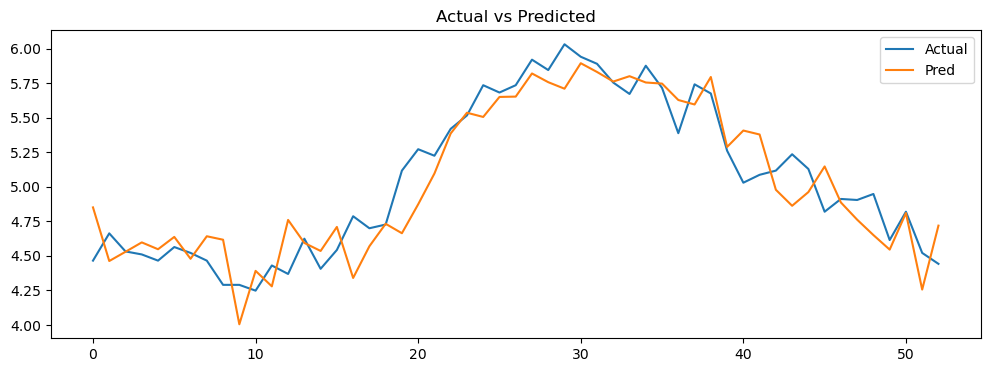

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Pred")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
threshold = np.percentile(y_train, 90)

high_risk_true = y_test > threshold
high_risk_pred = y_pred > threshold

recall = (high_risk_true & high_risk_pred).sum() / high_risk_true.sum()
print("High-risk recall:", recall)

High-risk recall: 0.8571428571428571


### 2.1.4 LightGBM

In [ ]:
# TimeSeriesSplit 활용하여 하이퍼파라미터 튜닝

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, mean_squared_error
import lightgbm as lgb

# -------------------------
# 1) scoring: RMSE (작을수록 좋게)
# -------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

# -------------------------
# 2) TimeSeriesSplit
# -------------------------
tscv = TimeSeriesSplit(n_splits=5)

# -------------------------
# 3) Pipeline + 탐색공간
# -------------------------
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", lgb.LGBMRegressor(random_state=42, verbosity=-1))
])

param_dist = {
    "model__n_estimators": [300, 500, 800, 1200],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [-1, 3, 4, 5, 6],
    "model__num_leaves": [15, 31, 63, 127],
    "model__min_child_samples": [5, 10, 20, 30, 50],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.1, 0.5, 1.0],
    "model__reg_lambda": [0, 0.1, 0.5, 1.0],
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring=rmse_scorer,
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
    refit=True,                # CV로 best 찾은 다음, train 전체로 다시 학습
    return_train_score=True
)

# -------------------------
# 4) 튜닝 + CV 성능 확인
# -------------------------
search.fit(X_train, y_train)

cv_best_rmse = -search.best_score_
print("CV best RMSE:", cv_best_rmse)
print("Best params:", search.best_params_)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-

CV best RMSE: 0.30291971210586927
Best params: {'model__subsample': 1.0, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0, 'model__num_leaves': 63, 'model__n_estimators': 300, 'model__min_child_samples': 10, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.6}


In [ ]:
# final model 성능 확인

best_model=search.best_estimator_

y_pred=best_model.predict(X_test)

test_rmse=np.sqrt(mean_squared_error(y_test, y_pred))
bias = (y_test - y_pred).mean()
normalized_rmse=test_rmse/y_test.mean()
print("TEST RMSE:", test_rmse)
print("TEST Bias (mean resid):", bias)
print('Normalized RMSE:', normalized_rmse)

TEST RMSE: 0.18250869436636452
TEST Bias (mean resid): 0.0023542320849513835
Normalized RMSE: 0.03614137341274129


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# feature importance 확인

final_lgb=best_model.named_steps['model']

imp = pd.Series(final_lgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 20 feature importance:")
print(imp.head(30))


Top 20 feature importance:
temp_lag0                      402
cases_lag1                     351
humidity_lag0                  298
temp_lag1                      293
humidity_lag1                  282
cases_lag2                     270
cases_lag3                     250
rain_diff_lag3                 249
humidity_lag2                  248
rain_nat_lag3                  233
temp_lag2                      230
month_cos                      128
month_sin                       73
erer_lag3                       47
avg_flood_intensity_lag2        21
pop_weighted_intensity_lag2     15
pop_area_lag2                   12
sum_flood_area_lag2              4
sum_weighted_area_lag2           4
dtype: int32


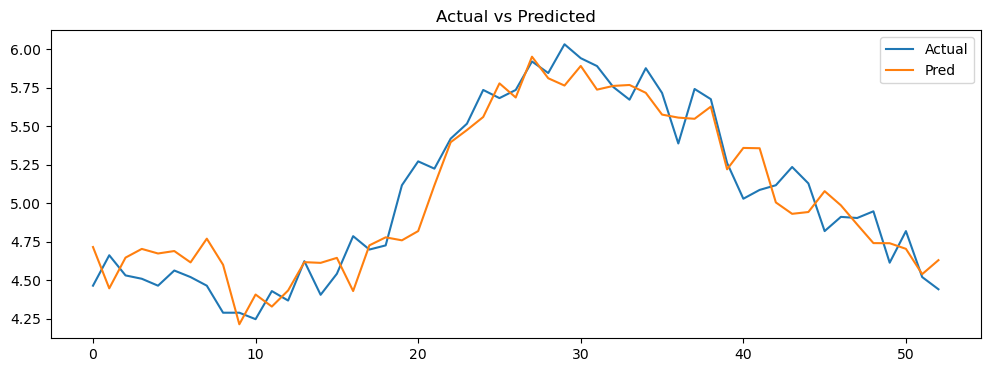

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Pred")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
# 극단값 예측력

threshold = np.percentile(y_train, 90)

high_risk_true = y_test > threshold
high_risk_pred = y_pred > threshold

recall = (high_risk_true & high_risk_pred).sum() / high_risk_true.sum()
print("High-risk recall:", recall)

High-risk recall: 0.7857142857142857


## 2.2 잔차 기반 RandomForest

$$
\hat{Y}=\hat{Y}^\text{AR}+\widehat{resid}
$$

### 2.2.1 전처리

In [ ]:
df=df.sort_values(['year', 'week'])

df2=df.drop(columns=['week', 'week_start', 'cases_virus', 'cases_protozoa'])
df2=df2.rename(columns={'cases_bacteria':'cases'})
df2.columns

# 계절성 변수 추가
df2['month_sin']=np.sin(2*np.pi*df2['month']/12)
df2['month_cos']=np.cos(2*np.pi*df2['month']/12)

In [ ]:
# 지연 변수 생성
cols=['rain_nat', 'erer', 'rain_diff']
#cols=['erer', 'rain_diff']
df3=make_lag(df2, cols, [3])

cols=['pop_area', 'sum_weighted_area', 'sum_flood_area','avg_flood_intensity', 'pop_weighted_intensity']
#cols=['avg_flood_intensity', 'sum_weighted_area']
df3=make_lag(df3, cols, [2])

cols=['cases']
df3=make_lag(df3, cols, [0, 1, 2, 3])

cols=['temp', 'humidity']
#cols=['temp']
df3=make_lag(df3, cols, [0, 1, 2])

In [ ]:
df3.columns

Index(['year', 'rain_nat', 'erer', 'rain_diff', 'water_temp', 'DO', 'BOD',
       'COD', 'pH', 'coli_log_mean', 'coli_mean', 'cases', 'temp', 'humidity',
       'pop_area', 'sum_weighted_area', 'sum_flood_area',
       'avg_flood_intensity', 'pop_weighted_intensity', 'month', 'month_sin',
       'month_cos', 'rain_nat_lag3', 'erer_lag3', 'rain_diff_lag3',
       'pop_area_lag2', 'sum_weighted_area_lag2', 'sum_flood_area_lag2',
       'avg_flood_intensity_lag2', 'pop_weighted_intensity_lag2', 'cases_lag0',
       'cases_lag1', 'cases_lag2', 'cases_lag3', 'temp_lag0', 'temp_lag1',
       'temp_lag2', 'humidity_lag0', 'humidity_lag1', 'humidity_lag2'],
      dtype='object')

In [ ]:
# 중복 변수 삭제
df4=df3.drop(columns=['rain_nat', 'erer', 'rain_diff', 'pop_area', 'sum_weighted_area', 'sum_flood_area',
       'avg_flood_intensity', 'pop_weighted_intensity', 'temp', 'humidity', 'month', 'cases_lag0', 'water_temp', 'DO', 'BOD', 'COD', 'pH','coli_log_mean', 'coli_mean'])

# 'water_temp', 'DO', 'BOD', 'COD', 'pH','coli_log_mean', 'coli_mean'

In [ ]:
# test/train set 분리 : 2022년 test set으로, 나머지 train set으로 분리

ar_cols=['cases_lag1', 'cases_lag2', 'cases_lag3', 'cases']
clim_cols=['rain_nat_lag3', 'erer_lag3',
           'rain_diff_lag3', 'pop_area_lag2', 'sum_weighted_area_lag2',
           'sum_flood_area_lag2', 'avg_flood_intensity_lag2',
           'pop_weighted_intensity_lag2','cases']

df_test=df4.loc[df4['year']==2022, :].drop(columns='year')
df_train=df4.loc[df4['year'].isin(range(2015, 2022)), :].drop(columns='year')

# AR-only 변수 생성
df_test_ar=df_test[ar_cols]
df_train_ar=df_train[ar_cols]

X_train_ar=df_train_ar.drop(columns='cases')
y_train=df_train['cases']

X_test_ar=df_test_ar.drop(columns='cases')
y_test=df_test['cases']

# climate 변수 생성

df_test_clim=df_test[clim_cols]
df_train_clim=df_train[clim_cols]

X_train_clim=df_train_clim.drop(columns='cases')
X_test_clim=df_test_clim.drop(columns='cases')

### 2.2.2 AR-only 모델 및 잔차 생성

In [ ]:
# TimeSeriesSplit 활용하여 AR-only 모델 하이퍼파라미터 튜닝


from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

tscv = TimeSeriesSplit(n_splits=5)

pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42, verbose=0))
])
param_dist = {
    "model__n_estimators": [200, 500, 800, 1200],
    "model__max_depth": [None, 3, 5, 8, 12, 20],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8, 12],
    "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0],
    "model__bootstrap": [True, False]
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring=rmse_scorer,
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
    refit=True,
    return_train_score=True
)

search.fit(X_train_ar, y_train)

cv_best_rmse = -search.best_score_
print("CV best RMSE:", cv_best_rmse)
print("Best params:", search.best_params_)

CV best RMSE: 43.25748674534744
Best params: {'model__n_estimators': 1200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 0.7, 'model__max_depth': 20, 'model__bootstrap': True}


In [ ]:
# 잔차 생성
best_model=search.best_estimator_
ar_model=best_model.named_steps['model']

yhat_train_ar=ar_model.predict(X_train_ar)
yhat_test_ar=ar_model.predict(X_test_ar)

resid_train=y_train-yhat_train_ar
resid_test=y_test-yhat_test_ar

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


### 2.2.3 잔차를 강수, 침수 변수로 예측하는 RF

In [ ]:
# climate LightGBM
# resid_train을 타겟으로 학습
search.fit(X_train_clim, resid_train)

print("Residual-model CV best RMSE:", -search.best_score_)
print("Residual-model best params:", search.best_params_)

Residual-model CV best RMSE: 24.264610157982542
Residual-model best params: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 12, 'model__max_features': 0.3, 'model__max_depth': 5, 'model__bootstrap': True}


In [ ]:
# 잔차 예측
resid_model = search.best_estimator_.named_steps['model']
resid_pred_test = resid_model.predict(X_test_clim)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


### 2.2.4 최종 예측 복원 및 성능 비교

In [ ]:
yhat_test_final = yhat_test_ar + resid_pred_test

rmse_ar = rmse(y_test, yhat_test_ar)
rmse_final = rmse(y_test, yhat_test_final)

print("AR-only TEST RMSE:", rmse_ar)
print("AR + residual(climate) TEST RMSE:", rmse_final)
print("ΔRMSE (improvement):", rmse_ar - rmse_final)

AR-only TEST RMSE: 35.44740000589252
AR + residual(climate) TEST RMSE: 34.530739777253594
ΔRMSE (improvement): 0.9166602286389249


In [ ]:
imp = pd.Series(resid_model.feature_importances_, index=X_train_clim.columns).sort_values(ascending=False)
imp

rain_nat_lag3                  0.285064
rain_diff_lag3                 0.246364
erer_lag3                      0.197128
avg_flood_intensity_lag2       0.073867
pop_weighted_intensity_lag2    0.063266
pop_area_lag2                  0.049552
sum_weighted_area_lag2         0.047413
sum_flood_area_lag2            0.037345
dtype: float64

# [기타] 음이항 회귀 (추후 고려)-안 봐도 됨

## 1.2 변수 선택

### 1.2.1 상관계수 확인

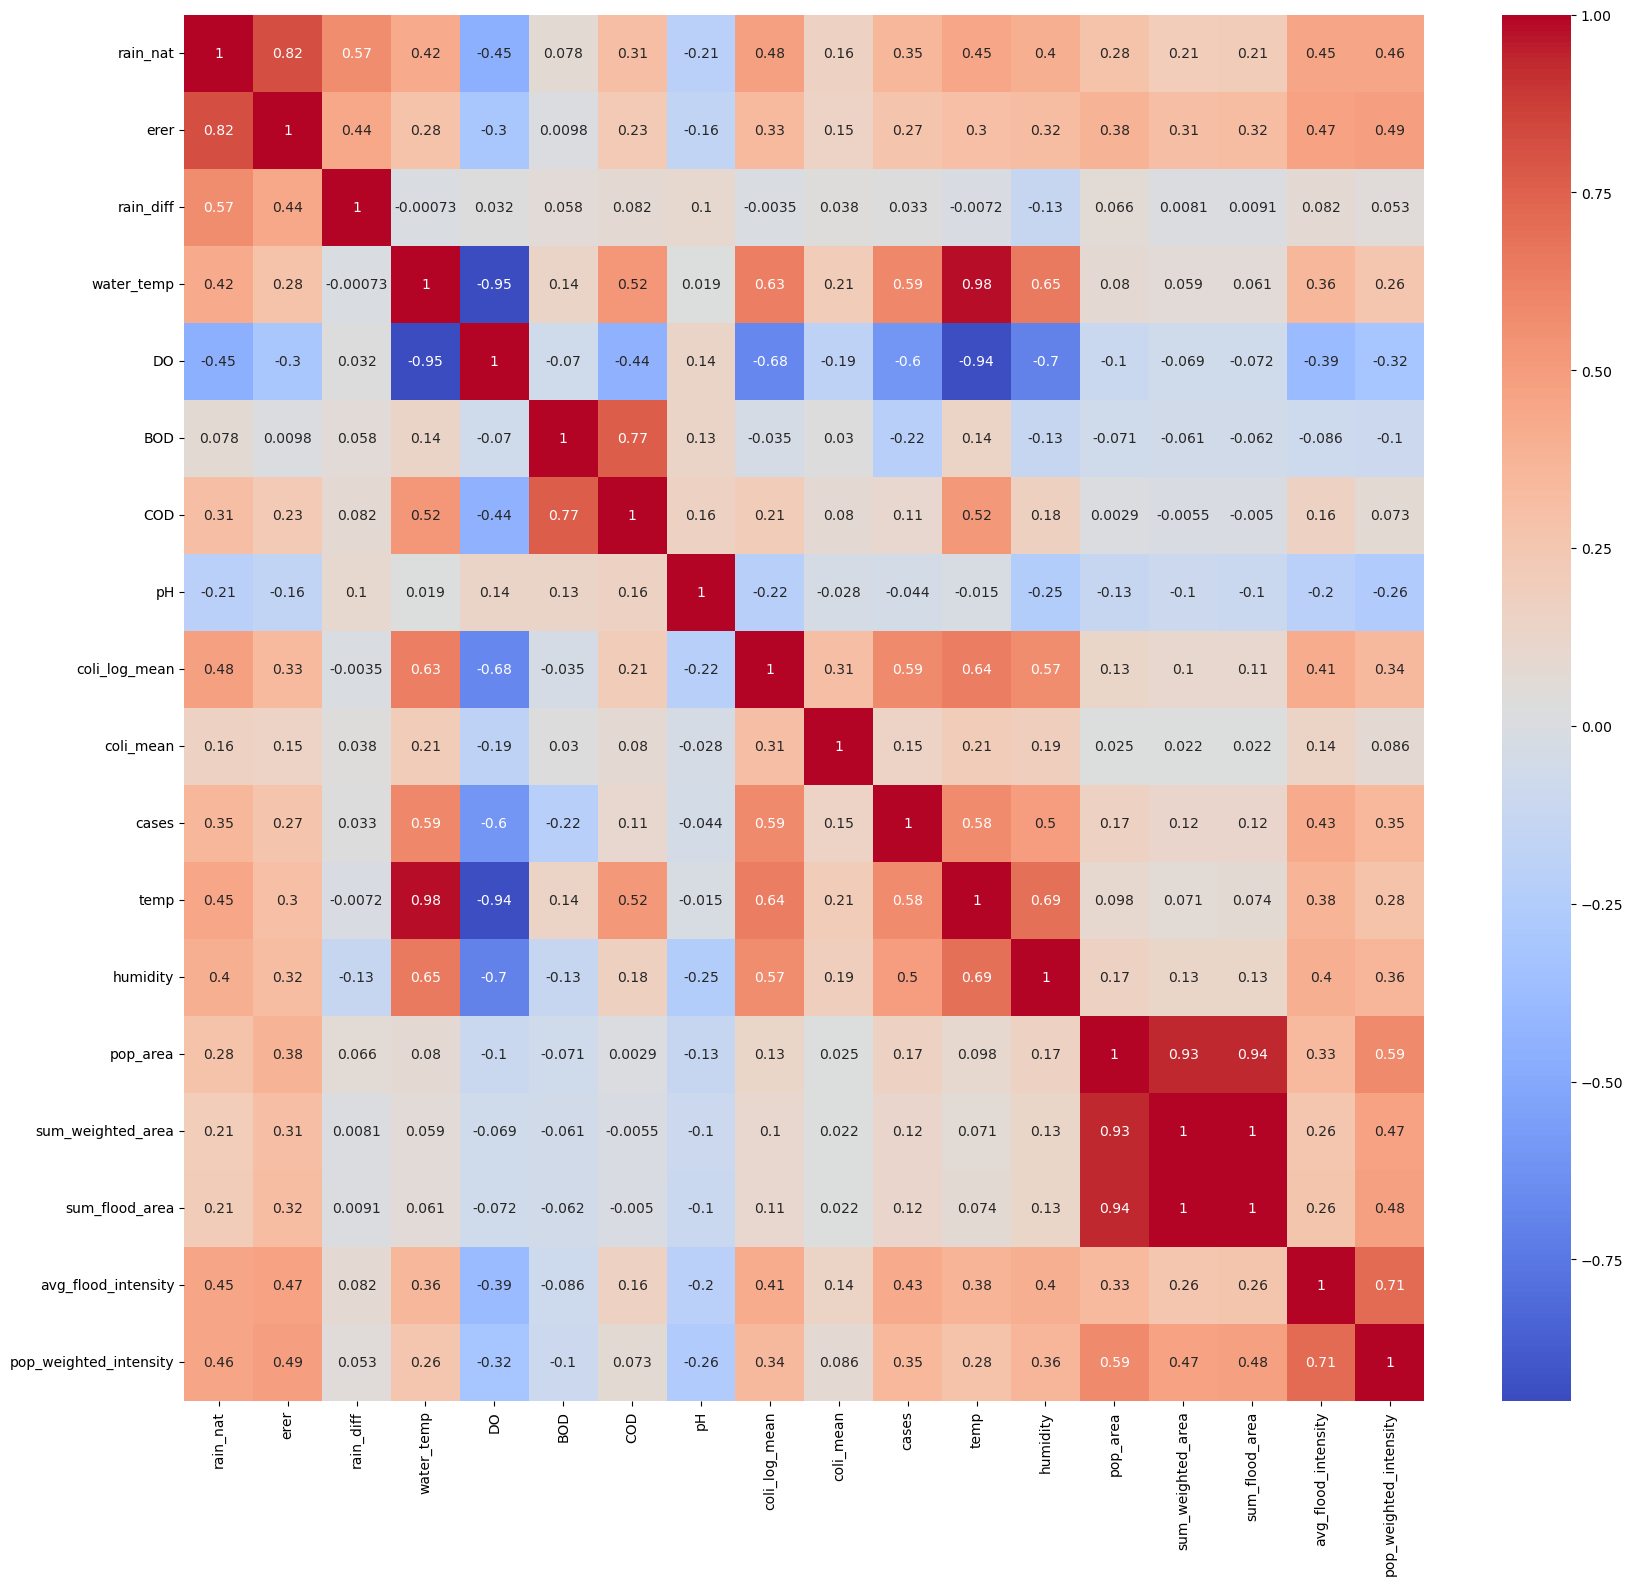

In [ ]:
corr=df2.corr()
plt.figure(figsize=(20, 18))
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.show()

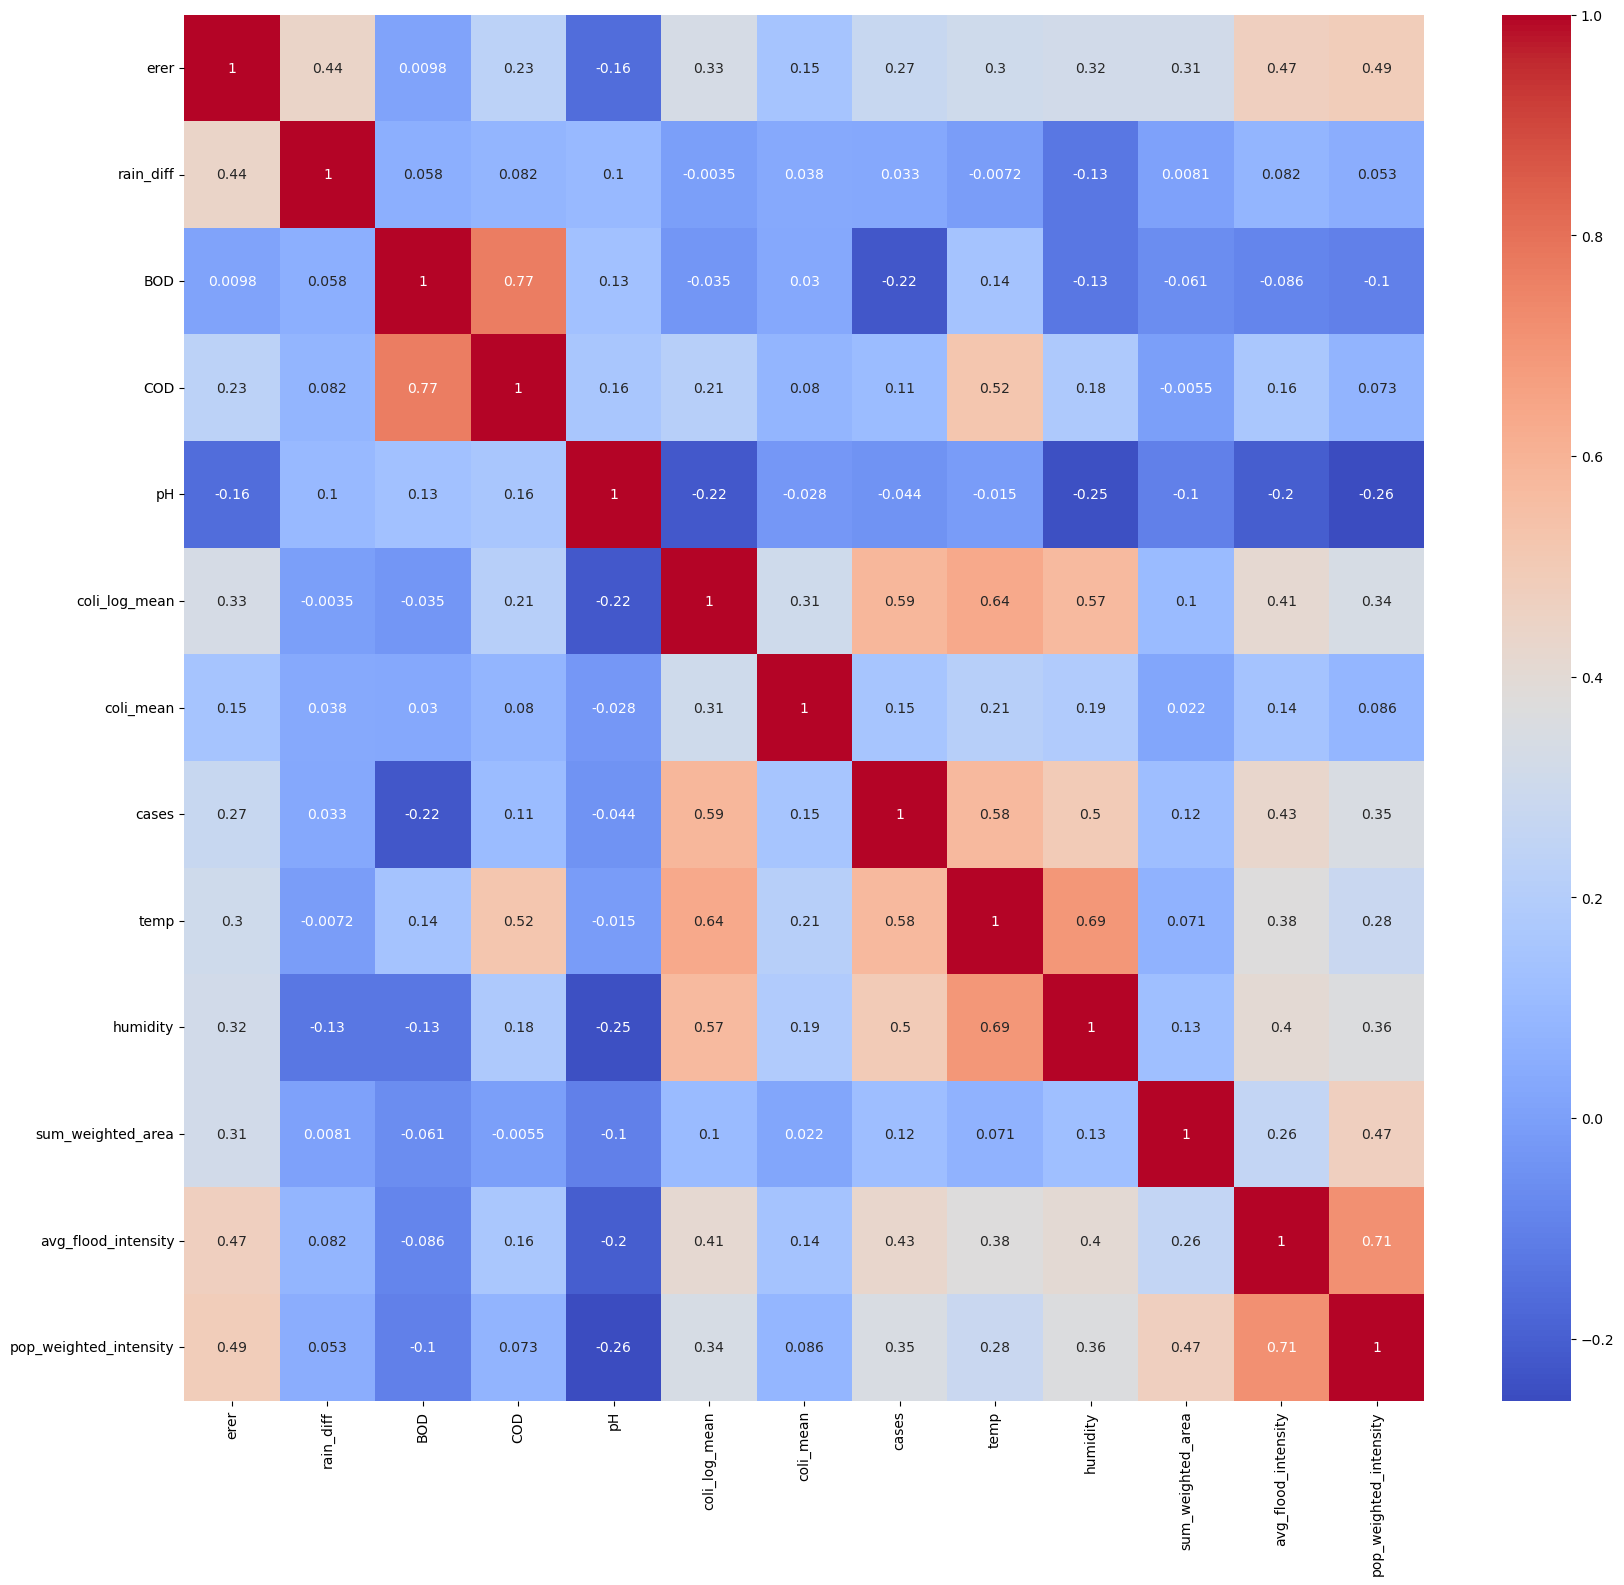

In [ ]:
corr=df2.drop(columns=['rain_nat', 'water_temp', 'DO', 'sum_flood_area', 'pop_area']).corr()
plt.figure(figsize=(20, 18))
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.show()

상관계수 0.7 이상 변수 제거

rain_nat, water_temp, DO, sum_flood_area, pop_area, temp, pop_weighted_intensity, COD 제거

In [ ]:
df3=df2.drop(columns=['rain_nat', 'water_temp', 'DO', 'sum_flood_area',
                      'pop_area', 'COD', 'pop_weighted_intensity'])

### 1.2.2 VIF 확인

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X=df3.drop(columns=['cases'])
X=X.dropna()
vif=pd.DataFrame()
vif['VIF Factor']=[variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['features']=X.columns
vif.sort_values('VIF Factor', ascending=False)

,VIF Factor,features
3,183.511253,pH
4,152.433158,coli_log_mean
7,101.646608,humidity
2,13.195632,BOD
6,6.885826,temp
0,2.187944,erer
9,1.722266,avg_flood_intensity
1,1.441249,rain_diff
5,1.221022,coli_mean
8,1.163858,sum_weighted_area


In [ ]:
# pH 제거 후 VIF 확인
X=df3.drop(columns=['cases','pH'])
X=X.dropna()
vif=pd.DataFrame()
vif['VIF Factor']=[variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['features']=X.columns
vif.sort_values('VIF Factor', ascending=False)

,VIF Factor,features
3,80.842004,coli_log_mean
6,76.334170,humidity
2,10.556908,BOD
5,4.606836,temp
0,2.086610,erer
8,1.675175,avg_flood_intensity
1,1.378101,rain_diff
4,1.189046,coli_mean
7,1.163180,sum_weighted_area


In [ ]:
# humidity 제거 후 VIF 확인
X=df3.drop(columns=['cases', 'pH',
                   'humidity'])
X=X.dropna()
vif=pd.DataFrame()
vif['VIF Factor']=[variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['features']=X.columns
vif.sort_values('VIF Factor', ascending=False)

,VIF Factor,features
3,13.107556,coli_log_mean
2,10.537608,BOD
5,4.165301,temp
0,2.068844,erer
7,1.675127,avg_flood_intensity
1,1.332596,rain_diff
4,1.175882,coli_mean
6,1.163056,sum_weighted_area


In [ ]:
# coli_log_mean 제거 후 VIF 확인
X=df3.drop(columns=['cases', 'pH',
                   'humidity', 'coli_log_mean'])
X=X.dropna()
vif=pd.DataFrame()
vif['VIF Factor']=[variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['features']=X.columns
vif.sort_values('VIF Factor', ascending=False)

,VIF Factor,features
4,3.637492,temp
2,2.853327,BOD
0,2.067360,erer
6,1.651556,avg_flood_intensity
1,1.326772,rain_diff
3,1.170471,coli_mean
5,1.162265,sum_weighted_area


## 1.3 음이항 회귀

In [ ]:
df2=df.drop(columns=['week', 'week_start', 'cases_virus', 'cases_protozoa'])
df2=df2.rename(columns={'cases_bacteria':'cases'})
df2.columns

# 계절성 변수 추가
df2['month_sin']=np.sin(2*np.pi*df2['month']/12)
df2['month_cos']=np.cos(2*np.pi*df2['month']/12)

df4=df2[['temp', 'BOD', 'avg_flood_intensity', 'erer', 'sum_weighted_area', 'rain_diff', 'coli_mean', 'cases', 'month_cos', 'month_sin']]

In [ ]:
def make_lag(df, cols, lags):
    df=df.copy()

    for c in cols:
        for l in lags:
            df[f'{c}_lag{l}']=df[c].shift(l)
    return df

In [ ]:
cols=['erer', 'rain_diff']
#cols=['erer', 'rain_diff']
df4=make_lag(df4, cols, [3])

cols=['sum_weighted_area', 'avg_flood_intensity']
#cols=['avg_flood_intensity', 'sum_weighted_area']
df4=make_lag(df4, cols, [2])

cols=['temp', 'cases']
#cols=['temp']
df4=make_lag(df4, cols, [1, 2, 3])

In [ ]:
# 스케일링
from sklearn.preprocessing import StandardScaler

cols = [
    'temp_lag1', 'temp_lag2', 'temp_lag3',
    'cases_lag1', 'cases_lag2', 'cases_lag3',
    'avg_flood_intensity_lag2',
    'sum_weighted_area_lag2',
    'erer_lag3',
    'rain_diff_lag3'
]

scaler = StandardScaler()

df4[cols] = scaler.fit_transform(df4[cols])

In [ ]:
df5=df4.dropna()

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

formula = """
cases ~ temp_lag1 + temp_lag2 + temp_lag3
+ avg_flood_intensity_lag2
+ sum_weighted_area_lag2
+ erer_lag3 + rain_diff_lag3
+ month_sin + month_cos
"""

model=smf.glm(
    formula=formula,
    data=df5,
    family=sm.families.NegativeBinomial()
).fit()
model.summary()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  cases   No. Observations:                  415
Model:                            GLM   Df Residuals:                      405
Model Family:        NegativeBinomial   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2445.0
Date:                Sun, 22 Feb 2026   Deviance:                       106.76
Time:                        00:08:23   Pearson chi2:                     81.3
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1597
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    4.8800      0.049     98.837      0.000       4.783       4.977
temp_lag1                   -0.0073      0.240     -0.030      0.976      -0.478       0.463
temp_lag2                   -0.0360      0.248     -0.145      0.885      -0.523       0.451
temp_lag3                   -0.0765      0.233     -0.329      0.742      -0.532       0.379
avg_flood_intensity_lag2     0.0522      0.057      0.911      0.362      -0.060       0.165
sum_weighted_area_lag2      -0.0036      0.051     -0.070      0.945      -0.104       0.097
erer_lag3                    0.0220      0.061      0.363      0.717      -0.097       0.141
rain_diff_lag3              -0.0025      0.056     -0.045      0.964      -0.112       0.107
month_sin                   -0.5943      0.240     -2.481      0.013      -1.064      -0.125
month_cos                   -0.3718      0.199     -1.867      0.062      -0.762       0.019
============================================================================================
"""